
The lecture goal here is to fit polynomials of different degrees to some noisy data, use a validation set to spot the best one (avoiding underfitting or overfitting), and visualize it all. We're using a sine wave with noise as an example, but this works for any regression task.
**Step 1: Generate Your Data**
Start by creating sample data to work with. You need training data (what you'll fit the model to) and validation data (to check how well it generalizes). Add some noise to mimic real-world messiness.

Why? Models learn from training data but get tested on unseen data to catch if they're memorizing noise instead of the pattern.
Algorithmically:
Pick a range for x (e.g., from 0 to 1).
Compute the true y values (e.g., y = sin(2πx)).
Add random noise to y for realism.
Split into training (fewer points, noisy) and validation (more points, also noisy).

Tips: Use a random seed for reproducibility so you get the same results every time.

**Step 2: Prepare to Test Different Polynomial Degrees
Decide on a max degree to try (e.g., up to 15). You'll loop through degrees from 1 up to that max, fitting a model each time.**

Why? Low degrees might underfit (too simple, misses the curve). High degrees overfit (wiggles to hit every noisy point but fails on new data).
Algorithmically:
Initialize empty lists/arrays for training errors and validation errors.
For each degree d from 1 to max:
Fit the polynomial.
Predict on training and validation sets.
Calculate errors.

Later, find the degree with the lowest validation error.


**Step 3: Fit the Polynomial Model for Each Degree
For each degree, create a polynomial model and train it on the data. This solves for coefficients that minimize the squared error.**

Why? Polynomials are flexible curves: degree 1 is a line, degree 2 a parabola, and so on.
Algorithmically:
Transform your x data into polynomial features (e.g., for degree 3: [1, x, x², x³]).
Use linear regression on those features to find the best-fit coefficients.
(In code, tools like scikit-learn handle this neatly with a pipeline.)


**Step 4: Make Predictions and Calculate Errors
Once fitted, use the model to predict y values for both training and validation x's. Then measure how wrong it is**

Why? Training error drops as degree rises (model gets more complex), but validation error forms a U-shape—rising after the sweet spot due to overfitting.
Algorithmically:
Predictions: Plug x into the fitted polynomial.
Error: Mean Squared Error (MSE) = average of (actual y - predicted y)² for the set.
Store these for each degree.


**Step 5: Visualize the Fits (Optional but Helpful)
Plot the data, true function, and a few polynomial fits to see overfitting visually.**

Why? Plots make it obvious—low degrees are too straight, high ones wiggle wildly.
Algorithmically:
Scatter plot training points.
Line plot true function.
For select degrees (e.g., 1, 3, 7, 10), add dashed lines of predictions on a dense x grid.


**Step 6: Plot the Error Curves and Pick the Best Degree
Graph errors vs. degree to find the optimal one.**

Why? This is your "cross-validation curve"—validation error tells you the best balance.
Algorithmically:
Plot training MSE (decreasing line) and validation MSE (U-shape).
Find the degree with min validation MSE.
Mark it with a vertical line.

Tips: If validation error keeps dropping, your max degree might be too low or data too simple.

**Step 7: Interpret and Use the Best Model
Once you have the best degree, you could refit on all data or just note it for future use**.

Why? Now you have a model that's neither too simple nor too complex.
Algorithmically: Output the best degree and its error. Optionally, predict on new data.

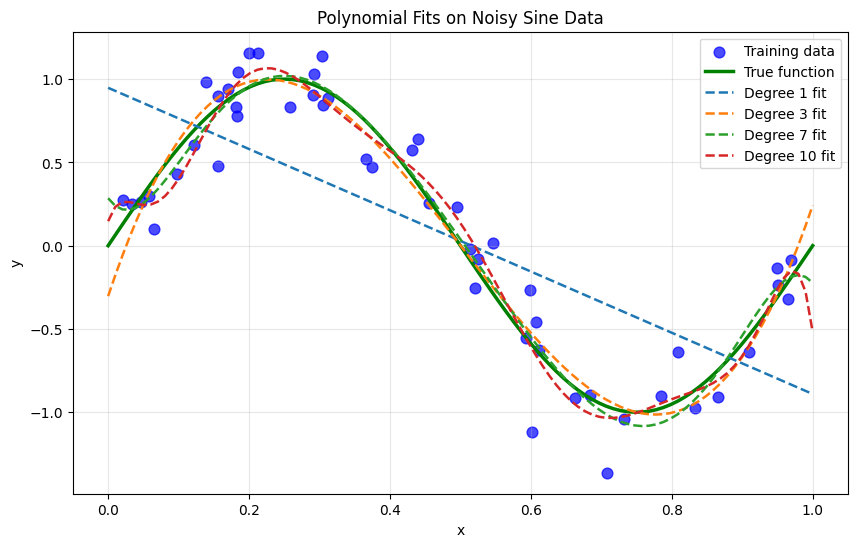

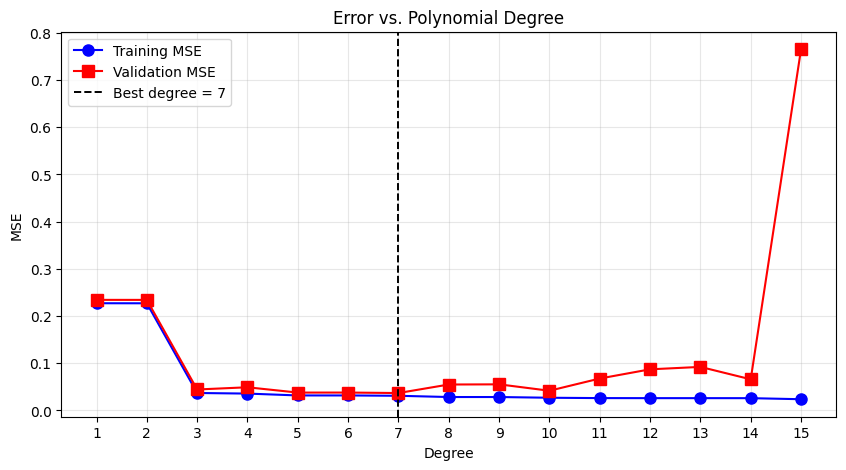

Best degree: 7 (validation MSE: 0.036996)


In [1]:
# Polynomial Fitting Demo in Python (scikit-learn + matplotlib)

import numpy as np
import matplotlib.pyplot as plt
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

# Step 1: Generate data
np.random.seed(42)  # For reproducibility
n_samples = 50
X_train = np.sort(np.random.rand(n_samples))[:, np.newaxis]  # Training x: random in [0,1]
y_true = np.sin(2 * np.pi * X_train.ravel())  # True y
y_train = y_true + 0.2 * np.random.randn(n_samples)  # Noisy training y

X_val = np.linspace(0, 1, 100)[:, np.newaxis]  # Validation x: even grid
y_val_true = np.sin(2 * np.pi * X_val.ravel())
y_val = y_val_true + 0.2 * np.random.randn(100)  # Noisy validation y

# Step 2: Prepare for degrees 1 to max
max_degree = 15
train_errors = []
val_errors = []

# Step 5: Set up plot for fits
plt.figure(figsize=(10, 6))
plt.scatter(X_train, y_train, color='blue', s=60, alpha=0.7, label='Training data')
plt.plot(X_val, y_val_true, color='green', linewidth=2.5, label='True function')

# Steps 3 & 4: Loop through degrees, fit, predict, calculate errors
for d in range(1, max_degree + 1):
    # Fit model (polynomial features + linear regression)
    model = make_pipeline(PolynomialFeatures(degree=d), LinearRegression())
    model.fit(X_train, y_train)

    # Predictions
    y_train_pred = model.predict(X_train)
    y_val_pred = model.predict(X_val)

    # Errors
    train_errors.append(mean_squared_error(y_train, y_train_pred))
    val_errors.append(mean_squared_error(y_val, y_val_pred))

    # Plot select fits (Step 5 continued)
    if d in [1, 3, 7, 10]:
        plt.plot(X_val, y_val_pred, '--', linewidth=1.8, label=f'Degree {d} fit')

# Finish fits plot
plt.title('Polynomial Fits on Noisy Sine Data')
plt.xlabel('x')
plt.ylabel('y')
plt.legend(loc='best')
plt.grid(True, alpha=0.3)
plt.show()

# Step 6: Error curves plot
plt.figure(figsize=(10, 5))
plt.plot(range(1, max_degree + 1), train_errors, 'o-', color='blue', linewidth=1.5, markersize=8, label='Training MSE')
plt.plot(range(1, max_degree + 1), val_errors, 's-', color='red', linewidth=1.5, markersize=8, label='Validation MSE')

# Step 7: Find and mark best
best_d = np.argmin(val_errors) + 1
plt.axvline(best_d, color='black', linestyle='--', linewidth=1.4, label=f'Best degree = {best_d}')

plt.title('Error vs. Polynomial Degree')
plt.xlabel('Degree')
plt.ylabel('MSE')
plt.legend(loc='best')
plt.grid(True, alpha=0.3)
plt.xticks(range(1, max_degree + 1))
plt.show()

print(f"Best degree: {best_d} (validation MSE: {min(val_errors):.6f})")